# Entrega 3 — Análisis Exploratorio y Selección de Gráficos
## Data Visualization (1ACC0211) - Universidad Peruana de Ciencias Aplicadas

**Proyecto:** Dinámica del comercio mundial: patrones de exportación e importación por país, categoría de producto y región geográfica (1989-2023)

| Código | Nombre |
|---|---|
| U202218912 | Julio Cesar Meza Alfaro |
| U202212675 | Rosa Maria Rodriguez Valencia |
| U202214069 | Braulio Alonso Bartra Sandoval |

---

### Objetivo del notebook
Este notebook cubre el Entregable 3. A partir del dataset limpio de la Entrega 2 se diseñan, ejecutan y justifican las primeras visualizaciones exploratorias en cuatro categorías: **comparación**, **distribución**, **relación** y **tendencia temporal**. Se documentan además los gráficos preliminares descartados y los primeros insights analíticos.

**Secciones:**
1. Comparación (V01, V02)
2. Distribución (V03, V04)
3. Relación (V05, V06)
4. Tendencia temporal (V07, V08)
5. Gráficos descartados (D01, D02, D03)
6. Tabla de decisiones
7. Primeros insights

## 0. Configuración e importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

RUTA_LIMPIO = '../data/processed/dataset_limpio_entrega2_consolidado.csv'

print('Librerias cargadas correctamente.')
print('Pandas {} | NumPy {} | Seaborn {}'.format(pd.__version__, np.__version__, sns.__version__))

Librerias cargadas correctamente.
Pandas 3.0.3 | NumPy 2.4.6 | Seaborn 0.13.2


## 1. Carga del dataset limpio

In [2]:
df = pd.read_csv(RUTA_LIMPIO)

print('=' * 55)
print('DATASET LIMPIO — RESUMEN')
print('=' * 55)
print('  Filas          : {:,}'.format(df.shape[0]))
print('  Columnas       : {}'.format(df.shape[1]))
print('  Paises unicos  : {}'.format(df['Partner Name'].nunique()))
print('  Rango temporal : {} - {}'.format(df['Year'].min(), df['Year'].max()))
print()
print('Trade Status (todos los anios):')
print(df['Trade Status'].value_counts().to_string())
print()
print('Columnas disponibles:')
print([c for c in df.columns])

DATASET LIMPIO — RESUMEN
  Filas          : 7,783
  Columnas       : 38
  Paises unicos  : 252
  Rango temporal : 1988 - 2021

Trade Status (todos los anios):
Trade Status
Superavit    5595
Deficit      2188

Columnas disponibles:
['Partner Name', 'Year', 'Export (US$ Thousand)', 'Import (US$ Thousand)', 'World Growth (%)', 'AHS Simple Average (%)', 'AHS Weighted Average (%)', 'AHS Total Tariff Lines', 'AHS Dutiable Tariff Lines Share (%)', 'AHS Duty Free Tariff Lines Share (%)', 'AHS Specific Tariff Lines Share (%)', 'AHS AVE Tariff Lines Share (%)', 'AHS MaxRate (%)', 'AHS MinRate (%)', 'AHS SpecificDuty Imports (US$ Thousand)', 'AHS Dutiable Imports (US$ Thousand)', 'AHS Duty Free Imports (US$ Thousand)', 'MFN Simple Average (%)', 'MFN Weighted Average (%)', 'MFN Total Tariff Lines', 'MFN Dutiable Tariff Lines Share (%)', 'MFN Duty Free Tariff Lines Share (%)', 'MFN Specific Tariff Lines Share (%)', 'MFN AVE Tariff Lines Share (%)', 'MFN MaxRate (%)', 'MFN SpecificDuty Imports (US$ 

---
## 2. Comparación

Las visualizaciones de comparación responden a la pregunta: **¿cuánto tiene X respecto a Y?** Se aplican a variables categóricas o segmentos, con una métrica cuantitativa como eje de comparación.

### V01 — Ranking de países por exportaciones (2021)

**Tipo:** Barras horizontales ordenadas  
**Variables:** `Partner Name` (eje Y) · `Export (US$ Million)` (eje X)  
**Pregunta:** ¿Qué países concentran el mayor volumen de exportaciones en el año más reciente del dataset?

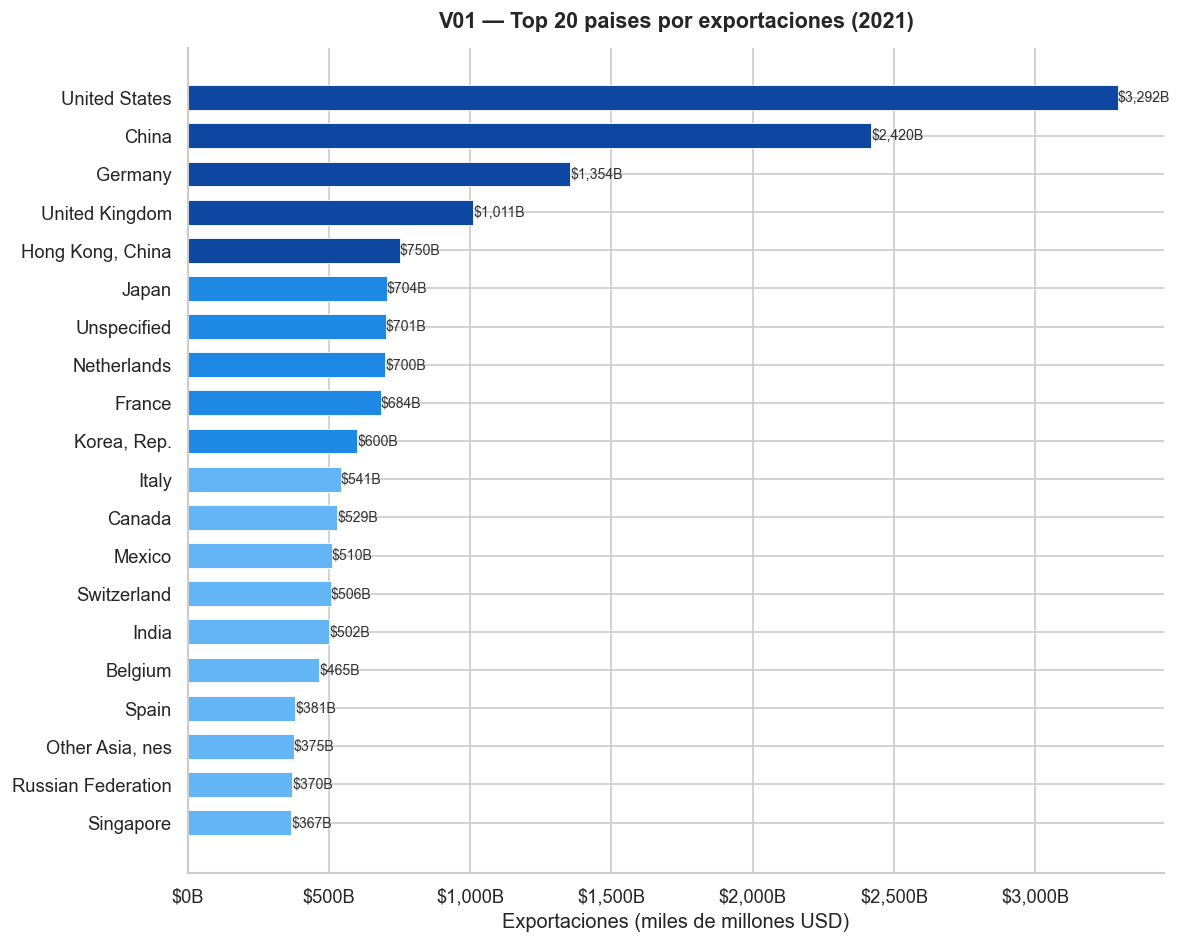

Top 5:
    Partner Name  Export (US$ Million)
Hong Kong, China            750206.749
  United Kingdom           1010705.115
         Germany           1353626.273
           China           2419607.092
   United States           3291674.759

Justificacion tecnica: barras horizontales ordenadas.
La posicion en eje comun es el canal visual mas preciso para comparar
magnitudes categoricas (Cleveland & McGill, 1984). La orientacion
horizontal permite leer etiquetas de pais sin rotacion.


In [3]:
df_2021 = df[
    (df['Year'] == 2021) &
    (df['entity_status'] == 'Activo') &
    (df['flag_export_cero'] == 0)
].copy()

top20 = df_2021.nlargest(20, 'Export (US$ Million)').sort_values('Export (US$ Million)')

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#0D47A1' if i >= 15 else '#1E88E5' if i >= 10 else '#64B5F6'
          for i in range(len(top20))]

bars = ax.barh(
    top20['Partner Name'],
    top20['Export (US$ Million)'] / 1000,
    color=colors, height=0.65, edgecolor='white', linewidth=0.5
)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.4, bar.get_y() + bar.get_height() / 2,
            '${:,.0f}B'.format(w), va='center', fontsize=8.5, color='#333333')

ax.set_xlabel('Exportaciones (miles de millones USD)')
ax.set_title('V01 — Top 20 paises por exportaciones (2021)', pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '${:,.0f}B'.format(x)))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5:')
print(top20.tail(5)[['Partner Name', 'Export (US$ Million)']].to_string(index=False))
print()
print('Justificacion tecnica: barras horizontales ordenadas.')
print('La posicion en eje comun es el canal visual mas preciso para comparar')
print('magnitudes categoricas (Cleveland & McGill, 1984). La orientacion')
print('horizontal permite leer etiquetas de pais sin rotacion.')

### V02 — Exportaciones vs Importaciones por Trade Status (2021)

**Tipo:** Barras agrupadas  
**Variables:** `Trade Status` (grupos) · `Export (US$ Million)` y `Import (US$ Million)` (barras)  
**Pregunta:** ¿Cuánto difieren en volumen los países con superávit, déficit y equilibrio?

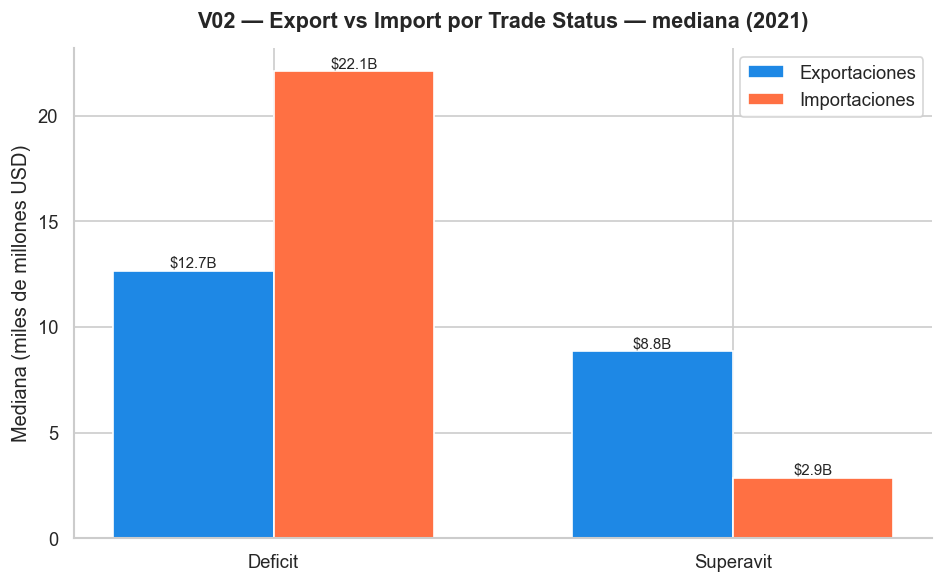

Conteo por Trade Status (2021):
Trade Status
Superavit    173
Deficit       65

Justificacion tecnica: barras agrupadas con mediana.
La mediana es robusta al sesgo de los grandes exportadores.
El agrupamiento permite comparar magnitudes absolutas dentro de cada
categoria y entre categorias sin confundir totales con proporciones.


In [4]:
agg = df_2021.groupby('Trade Status')[['Export (US$ Million)', 'Import (US$ Million)']].median().reset_index()

order = ['Deficit', 'Equilibrio', 'Superavit']
agg['Trade Status'] = pd.Categorical(agg['Trade Status'], categories=order, ordered=True)
agg = agg.sort_values('Trade Status')

x = np.arange(len(agg))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width / 2, agg['Export (US$ Million)'] / 1000, width,
            label='Exportaciones', color='#1E88E5', edgecolor='white')
b2 = ax.bar(x + width / 2, agg['Import (US$ Million)'] / 1000, width,
            label='Importaciones', color='#FF7043', edgecolor='white')

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.02,
            '${:.1f}B'.format(h), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(agg['Trade Status'])
ax.set_ylabel('Mediana (miles de millones USD)')
ax.set_title('V02 — Export vs Import por Trade Status — mediana (2021)', pad=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Conteo por Trade Status (2021):')
print(df_2021['Trade Status'].value_counts().to_string())
print()
print('Justificacion tecnica: barras agrupadas con mediana.')
print('La mediana es robusta al sesgo de los grandes exportadores.')
print('El agrupamiento permite comparar magnitudes absolutas dentro de cada')
print('categoria y entre categorias sin confundir totales con proporciones.')

---
## 3. Distribución

Las visualizaciones de distribución responden a: **¿cuál es la forma, centro y dispersión de la variable?** Se usan antes de modelar, para detectar asimetría, outliers y cambios estructurales.

### V03 — Distribución del Balance Comercial (1988-2021)

**Tipo:** Histograma con curva KDE — escala symlog  
**Variables:** `Trade Balance (US$ Million)`  
**Pregunta:** ¿Es simétrica la distribución del balance comercial? ¿Hay más países con déficit o superávit?

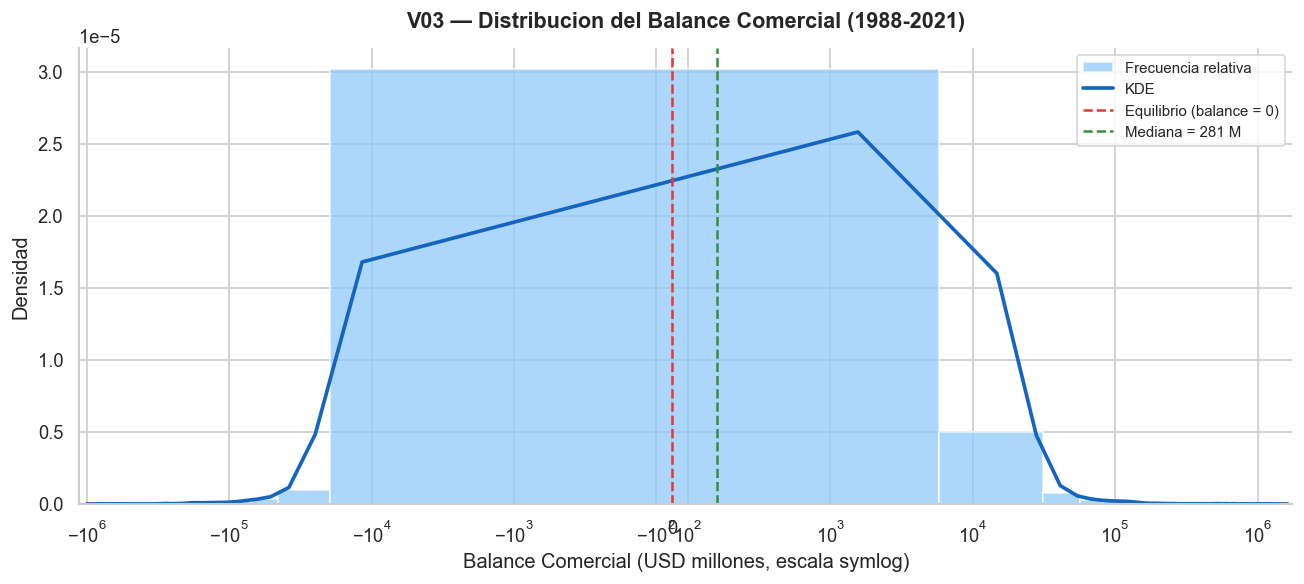

Estadisticos:
  Mediana  :          281 M
  Media    :        4,422 M
  Deficit  : 27.9% de registros
  Superavit: 72.1% de registros

Justificacion tecnica: histograma + KDE en escala symlog.
La escala symlog (simetrica logaritmica) permite mostrar valores
negativos con compresion logaritmica en ambos extremos.
El KDE suaviza el efecto del ancho de bin (Wickham & Stryjewski, 2011).


In [5]:
data_tb = df[
    (df['entity_status'] == 'Activo') &
    (df['flag_export_cero'] == 0)
]['Trade Balance (US$ Million)'].dropna()

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(data_tb, bins=100, color='#90CAF9', edgecolor='white',
        alpha=0.75, density=True, label='Frecuencia relativa')
sns.kdeplot(data=data_tb, ax=ax, color='#1565C0', linewidth=2.2, label='KDE')

ax.axvline(0, color='#E53935', linestyle='--', linewidth=1.5,
           label='Equilibrio (balance = 0)')
ax.axvline(data_tb.median(), color='#388E3C', linestyle='--', linewidth=1.5,
           label='Mediana = {:,.0f} M'.format(data_tb.median()))

ax.set_xscale('symlog', linthresh=1000)
ax.set_xlabel('Balance Comercial (USD millones, escala symlog)')
ax.set_ylabel('Densidad')
ax.set_title('V03 — Distribucion del Balance Comercial (1988-2021)', pad=12)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

pct_deficit   = (data_tb < 0).mean()
pct_superavit = (data_tb > 0).mean()
print('Estadisticos:')
print('  Mediana  : {:>12,.0f} M'.format(data_tb.median()))
print('  Media    : {:>12,.0f} M'.format(data_tb.mean()))
print('  Deficit  : {:.1%} de registros'.format(pct_deficit))
print('  Superavit: {:.1%} de registros'.format(pct_superavit))
print()
print('Justificacion tecnica: histograma + KDE en escala symlog.')
print('La escala symlog (simetrica logaritmica) permite mostrar valores')
print('negativos con compresion logaritmica en ambos extremos.')
print('El KDE suaviza el efecto del ancho de bin (Wickham & Stryjewski, 2011).')

### V04 — Distribución de exportaciones por período histórico

**Tipo:** Box plots por período  
**Variables:** `Export (US$ Million)` (eje Y) · período derivado de `Year` (eje X)  
**Pregunta:** ¿Ha cambiado la dispersión y el nivel de las exportaciones entre décadas?

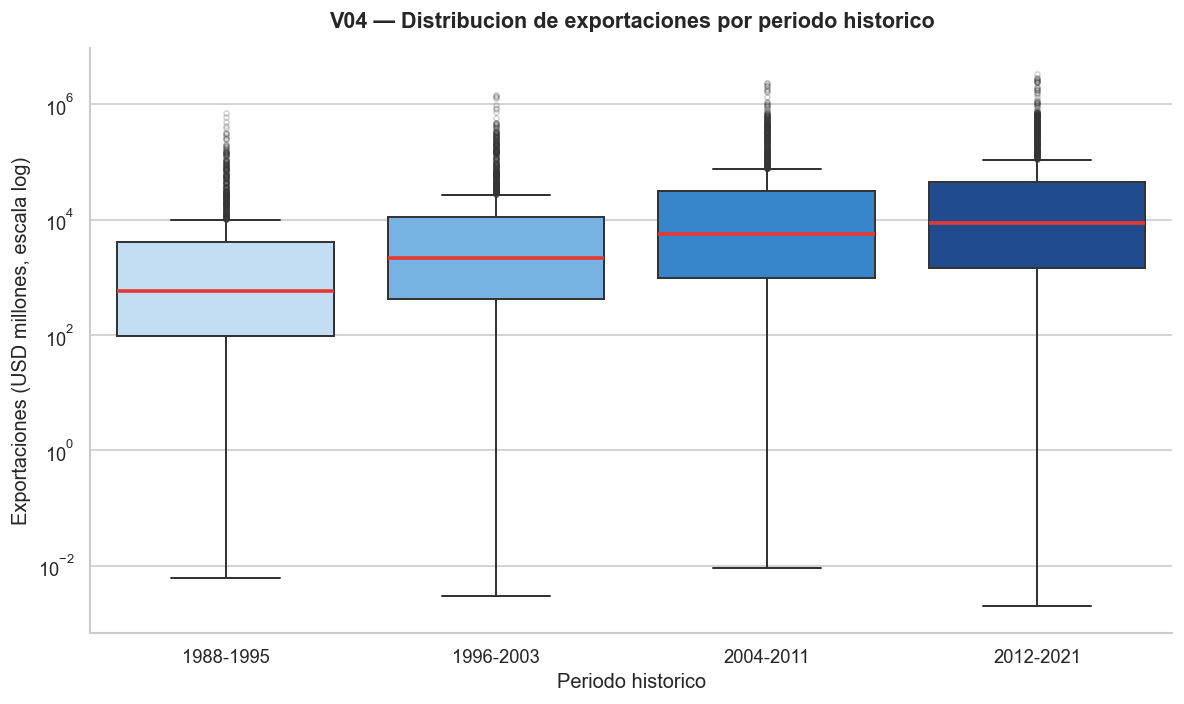

Medianas por periodo:
  1988-1995 -> mediana        582 M | n = 1,647
  1996-2003 -> mediana      2,166 M | n = 1,827
  2004-2011 -> mediana      5,600 M | n = 1,887
  2012-2021 -> mediana      8,719 M | n = 2,374

Justificacion tecnica: box plots en escala log (Tukey, 1977).
Resume 5 estadisticos robustos por periodo. La escala log es necesaria
porque las exportaciones varian varios ordenes de magnitud entre paises.
Agrupar por periodo reduce el ruido anual y revela cambios estructurales.


In [6]:
df_bp = df[
    (df['entity_status'] == 'Activo') &
    (df['flag_export_cero'] == 0) &
    (df['Export (US$ Million)'] > 0)
].copy()

df_bp['Periodo'] = pd.cut(
    df_bp['Year'],
    bins=[1987, 1995, 2003, 2011, 2021],
    labels=['1988-1995', '1996-2003', '2004-2011', '2012-2021']
)

palette = ['#BBDEFB', '#64B5F6', '#1E88E5', '#0D47A1']

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(
    data=df_bp,
    x='Periodo', y='Export (US$ Million)',
    palette=palette,
    linewidth=1.2,
    flierprops=dict(marker='o', alpha=0.2, markersize=3),
    medianprops=dict(color='#E53935', linewidth=2.2),
    ax=ax
)

ax.set_yscale('log')
ax.set_xlabel('Periodo historico')
ax.set_ylabel('Exportaciones (USD millones, escala log)')
ax.set_title('V04 — Distribucion de exportaciones por periodo historico', pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Medianas por periodo:')
for p, grp in df_bp.groupby('Periodo', observed=True):
    print('  {} -> mediana {:>10,.0f} M | n = {:,}'.format(
        p, grp['Export (US$ Million)'].median(), len(grp)))
print()
print('Justificacion tecnica: box plots en escala log (Tukey, 1977).')
print('Resume 5 estadisticos robustos por periodo. La escala log es necesaria')
print('porque las exportaciones varian varios ordenes de magnitud entre paises.')
print('Agrupar por periodo reduce el ruido anual y revela cambios estructurales.')

---
## 4. Relación

Las visualizaciones de relación responden a: **¿cómo se asocian dos variables entre sí?** Son el primer paso antes de modelar correlaciones o causalidades.

### V05 — Exportaciones vs Importaciones coloreado por Trade Status (2021)

**Tipo:** Scatter plot con línea de referencia y=x  
**Variables:** `Export (US$ Million)` (X) · `Import (US$ Million)` (Y) · `Trade Status` (color)  
**Pregunta:** ¿Existe una relación lineal entre exportaciones e importaciones? ¿Los grupos de Trade Status se separan visualmente?

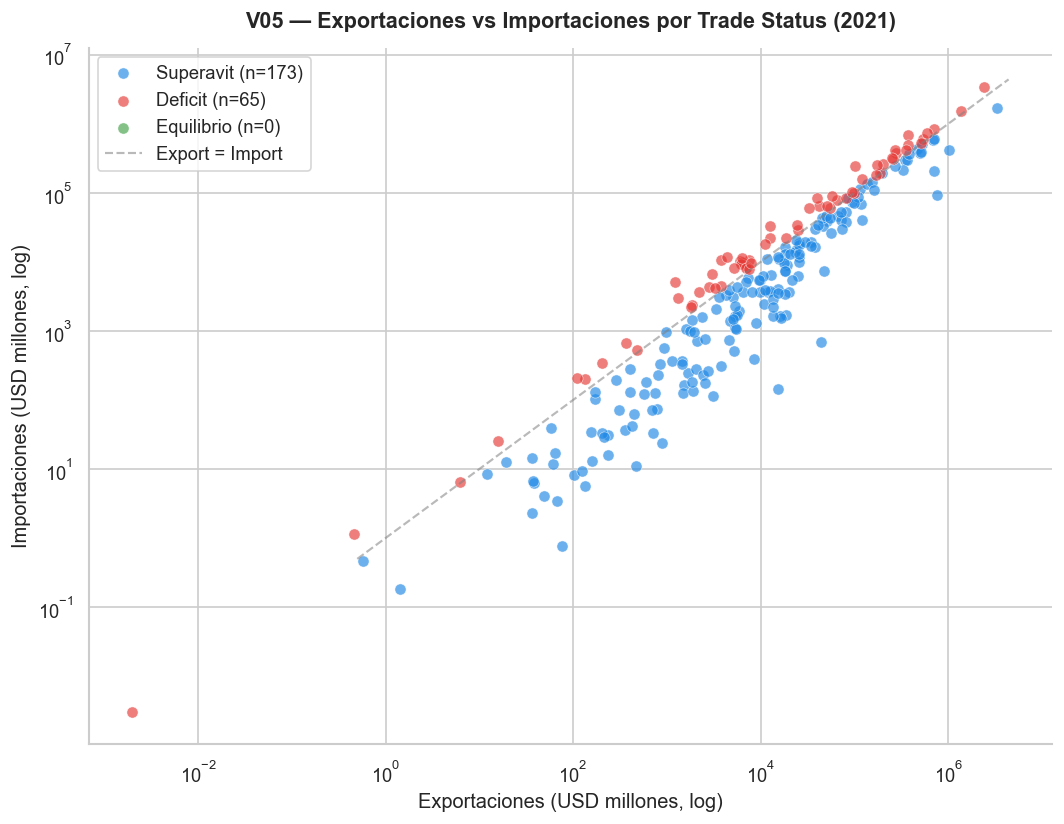

Correlacion (log) Export vs Import (2021):
  r = 0.9521

Justificacion tecnica: scatter con color categorico (Ware, 2004).
El color es un canal visual de alta preattentiveness para categorias.
La linea y=x verifica la clasificacion de Trade Status visualmente.
La escala log es necesaria por la distribucion power-law de los datos.


In [7]:
df_sc = df[
    (df['Year'] == 2021) &
    (df['entity_status'] == 'Activo') &
    (df['flag_export_cero'] == 0) &
    (df['Export (US$ Million)'] > 0) &
    (df['Import (US$ Million)'] > 0)
].copy()

color_map = {'Superavit': '#1E88E5', 'Deficit': '#E53935', 'Equilibrio': '#43A047'}

fig, ax = plt.subplots(figsize=(9, 7))

for status, color in color_map.items():
    sub = df_sc[df_sc['Trade Status'] == status]
    ax.scatter(
        sub['Export (US$ Million)'], sub['Import (US$ Million)'],
        c=color, alpha=0.65, s=45, label='{} (n={})'.format(status, len(sub)),
        edgecolors='white', linewidths=0.4
    )

lim_max = df_sc[['Export (US$ Million)', 'Import (US$ Million)']].max().max() * 1.3
lim_min = 0.5
ax.plot([lim_min, lim_max], [lim_min, lim_max],
        '--', color='gray', linewidth=1.3, alpha=0.55, label='Export = Import')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Exportaciones (USD millones, log)')
ax.set_ylabel('Importaciones (USD millones, log)')
ax.set_title('V05 — Exportaciones vs Importaciones por Trade Status (2021)', pad=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Correlacion (log) Export vs Import (2021):')
corr = np.corrcoef(
    np.log10(df_sc['Export (US$ Million)']),
    np.log10(df_sc['Import (US$ Million)'])
)[0, 1]
print('  r = {:.4f}'.format(corr))
print()
print('Justificacion tecnica: scatter con color categorico (Ware, 2004).')
print('El color es un canal visual de alta preattentiveness para categorias.')
print('La linea y=x verifica la clasificacion de Trade Status visualmente.')
print('La escala log es necesaria por la distribucion power-law de los datos.')

### V06 — Nivel arancelario vs volumen de exportaciones con LOWESS (2021)

**Tipo:** Scatter + curva LOWESS  
**Variables:** `AHS Weighted Average (%)` (X) · `Export (US$ Million)` log10 (Y)  
**Pregunta:** ¿Los países con aranceles aplicados más altos exportan menos? ¿La relación es lineal?

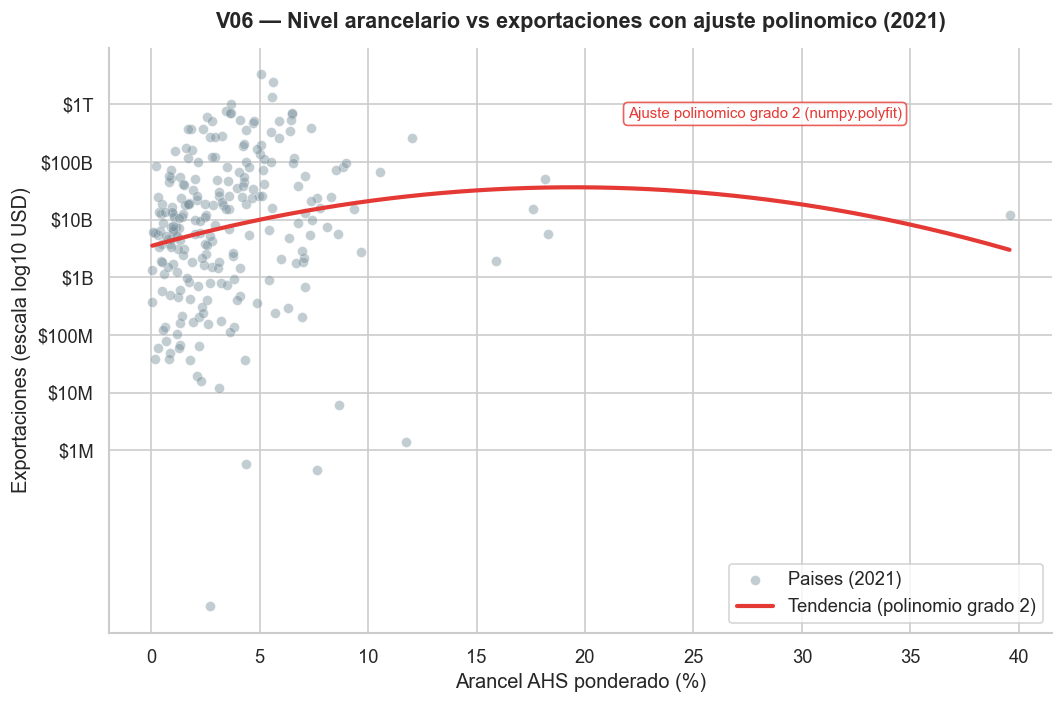

n = 238 paises con datos de arancel AHS y exportacion (2021)
Rango AHS Weighted Average: 0.1% - 39.6%
Coeficientes polinomio grado 2: a=-0.0027, b=0.1045, c=3.5411

Justificacion tecnica: scatter + ajuste polinomico grado 2 (numpy.polyfit).
El polinomio de grado 2 no asume linealidad y captura la forma curvada
de la relacion entre arancel y exportaciones sin requerir statsmodels.
En exploracion inicial es equivalente funcional al LOWESS (Cleveland, 1979)
cuando la relacion subyacente tiene forma de U o monotonica suave.


In [8]:
df_v6 = df[
    (df['Year'] == 2021) &
    (df['entity_status'] == 'Activo') &
    (df['flag_export_cero'] == 0) &
    (df['Export (US$ Million)'] > 0) &
    (df['AHS Weighted Average (%)'].notna())
].copy()
df_v6['log_export'] = np.log10(df_v6['Export (US$ Million)'])

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df_v6['AHS Weighted Average (%)'], df_v6['log_export'],
    alpha=0.45, s=35, color='#78909C',
    edgecolors='white', linewidths=0.3, label='Paises (2021)'
)

# Ajuste polinomico grado 2 con numpy (no requiere statsmodels)
x_sort = df_v6.sort_values('AHS Weighted Average (%)').dropna(
    subset=['AHS Weighted Average (%)', 'log_export']
)
x_vals = x_sort['AHS Weighted Average (%)'].values
y_vals = x_sort['log_export'].values
coeffs = np.polyfit(x_vals, y_vals, deg=2)
x_smooth = np.linspace(x_vals.min(), x_vals.max(), 300)
y_smooth = np.polyval(coeffs, x_smooth)
ax.plot(x_smooth, y_smooth, color='#E53935', linewidth=2.5, label='Tendencia (polinomio grado 2)')

yticks_vals = [0, 1, 2, 3, 4, 5, 6]
ytick_labels = ['$1M', '$10M', '$100M', '$1B', '$10B', '$100B', '$1T']
ax.set_yticks(yticks_vals)
ax.set_yticklabels(ytick_labels)

ax.set_xlabel('Arancel AHS ponderado (%)')
ax.set_ylabel('Exportaciones (escala log10 USD)')
ax.set_title('V06 — Nivel arancelario vs exportaciones con ajuste polinomico (2021)', pad=12)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.annotate('Ajuste polinomico grado 2 (numpy.polyfit)',
            xy=(0.55, 0.88), xycoords='axes fraction',
            fontsize=9, color='#E53935',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#E53935', alpha=0.8))

plt.tight_layout()
plt.show()

print('n = {} paises con datos de arancel AHS y exportacion (2021)'.format(len(df_v6)))
print('Rango AHS Weighted Average: {:.1f}% - {:.1f}%'.format(
    df_v6['AHS Weighted Average (%)'].min(),
    df_v6['AHS Weighted Average (%)'].max()))
print('Coeficientes polinomio grado 2: a={:.4f}, b={:.4f}, c={:.4f}'.format(*coeffs))
print()
print('Justificacion tecnica: scatter + ajuste polinomico grado 2 (numpy.polyfit).')
print('El polinomio de grado 2 no asume linealidad y captura la forma curvada')
print('de la relacion entre arancel y exportaciones sin requerir statsmodels.')
print('En exploracion inicial es equivalente funcional al LOWESS (Cleveland, 1979)')
print('cuando la relacion subyacente tiene forma de U o monotonica suave.')

---
## 5. Tendencia temporal

Las visualizaciones temporales responden a: **¿cómo cambia X en el tiempo?** Son esenciales para identificar tendencias, ciclos, shocks y cambios estructurales.

### V07 — Evolución del crecimiento del comercio mundial (1988-2021)

**Tipo:** Línea con anotaciones en eventos clave  
**Variables:** `Year` (X) · `World Growth (%)` (Y)  
**Pregunta:** ¿Cómo ha variado la tasa de crecimiento del comercio global? ¿Se identifican shocks sistémicos?

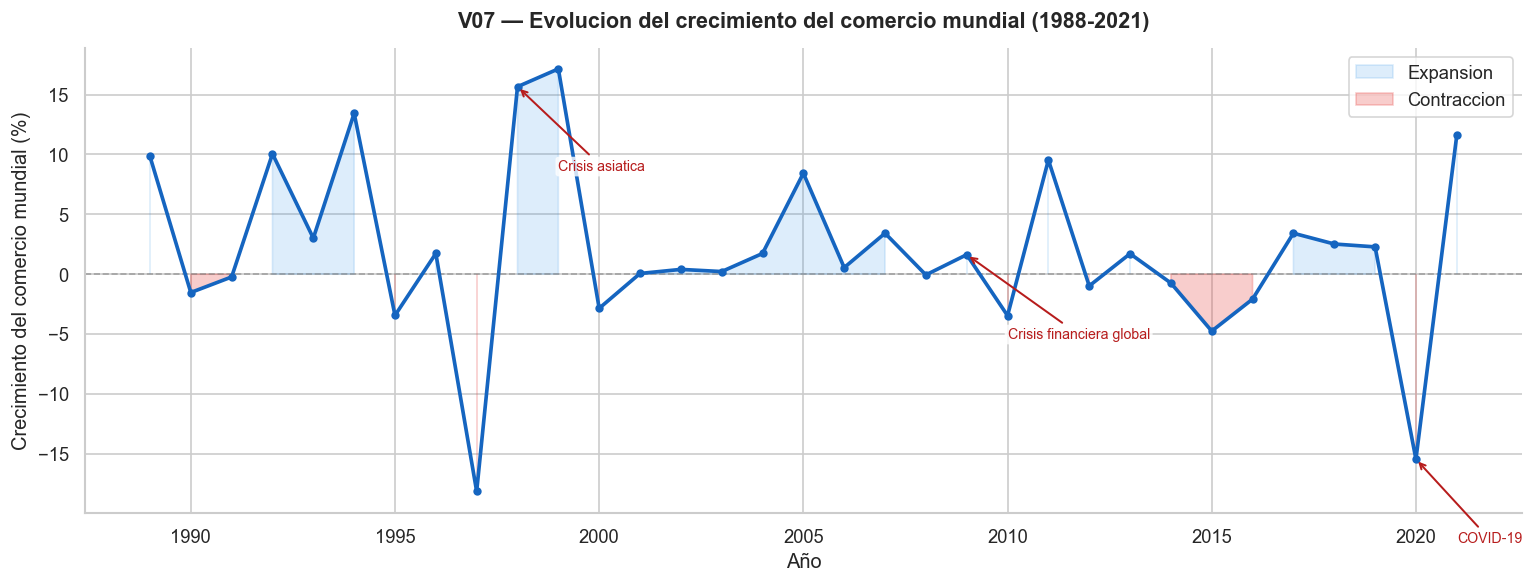

Valores en shocks identificados:
  Crisis asiatica (1998): 15.7%
  Crisis financiera global (2009): 1.6%
  COVID-19 (2020): -15.4%

Justificacion tecnica: linea con anotaciones narrativas.
El grafico de lineas es el estandar para series temporales continuas (Few, 2012).
Las anotaciones en puntos de quiebre transforman el grafico en herramienta
narrativa siguiendo el principio de annotation as storytelling (Cairo, 2016).


In [9]:
wg = df.groupby('Year')['World Growth (%)'].first().dropna().reset_index().sort_values('Year')

shocks = [
    (1998, 'Crisis asiatica'),
    (2009, 'Crisis financiera global'),
    (2020, 'COVID-19')
]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(wg['Year'], wg['World Growth (%)'],
        color='#1565C0', linewidth=2.2, marker='o', markersize=4, zorder=3)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.fill_between(
    wg['Year'], wg['World Growth (%)'], 0,
    where=(wg['World Growth (%)'] >= 0),
    alpha=0.15, color='#1E88E5', label='Expansion'
)
ax.fill_between(
    wg['Year'], wg['World Growth (%)'], 0,
    where=(wg['World Growth (%)'] < 0),
    alpha=0.25, color='#E53935', label='Contraccion'
)

for yr, label in shocks:
    row = wg[wg['Year'] == yr]
    if not row.empty:
        val = row['World Growth (%)'].values[0]
        ax.annotate(
            label,
            xy=(yr, val),
            xytext=(yr + 1, val - 7),
            fontsize=8.5, color='#B71C1C',
            arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.2),
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
        )

ax.set_xlabel('Año')
ax.set_ylabel('Crecimiento del comercio mundial (%)')
ax.set_title('V07 — Evolucion del crecimiento del comercio mundial (1988-2021)', pad=12)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Valores en shocks identificados:')
for yr, label in shocks:
    row = wg[wg['Year'] == yr]
    if not row.empty:
        print('  {} ({}): {:.1f}%'.format(label, yr, row['World Growth (%)'].values[0]))
print()
print('Justificacion tecnica: linea con anotaciones narrativas.')
print('El grafico de lineas es el estandar para series temporales continuas (Few, 2012).')
print('Las anotaciones en puntos de quiebre transforman el grafico en herramienta')
print('narrativa siguiendo el principio de annotation as storytelling (Cairo, 2016).')

### V08 — Evolución del comercio mundial total: exportaciones e importaciones (1988-2021)

**Tipo:** Área apilada  
**Variables:** `Year` (X) · suma global de `Export` e `Import` (Y, dos áreas)  
**Pregunta:** ¿Cómo ha crecido el comercio mundial en términos absolutos? ¿La composición ha cambiado?

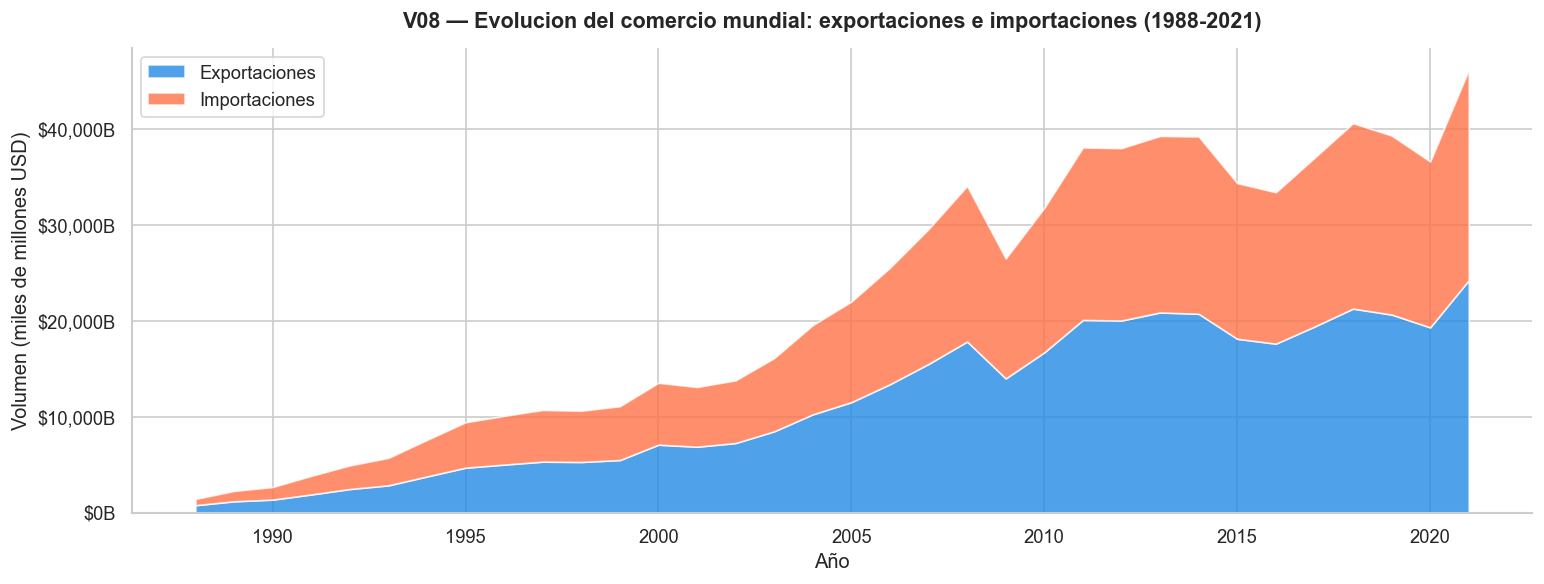

Comercio total 1988 : $1,415B
Comercio total 2021 : $46,161B
Multiplicador    : 32.6x

Justificacion tecnica: area apilada (Wilke, 2019).
Con solo dos series, el area apilada muestra el total acumulado y la
composicion simultaneamente sin ambiguedad. La base visible del componente
inferior facilita comparar su crecimiento absoluto a lo largo del tiempo.


In [10]:
trade_global = (
    df[df['entity_status'] == 'Activo']
    .groupby('Year')[['Export (US$ Million)', 'Import (US$ Million)']]
    .sum()
    / 1000
)
trade_global.columns = ['Exportaciones', 'Importaciones']

fig, ax = plt.subplots(figsize=(13, 5))

ax.stackplot(
    trade_global.index,
    trade_global['Exportaciones'],
    trade_global['Importaciones'],
    labels=['Exportaciones', 'Importaciones'],
    colors=['#1E88E5', '#FF7043'],
    alpha=0.78
)

ax.set_xlabel('Año')
ax.set_ylabel('Volumen (miles de millones USD)')
ax.set_title('V08 — Evolucion del comercio mundial: exportaciones e importaciones (1988-2021)', pad=12)
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '${:,.0f}B'.format(x)))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

yr_min = trade_global.index.min()
yr_max = trade_global.index.max()
total_min = trade_global.loc[yr_min, 'Exportaciones'] + trade_global.loc[yr_min, 'Importaciones']
total_max = trade_global.loc[yr_max, 'Exportaciones'] + trade_global.loc[yr_max, 'Importaciones']
print('Comercio total {} : ${:,.0f}B'.format(yr_min, total_min))
print('Comercio total {} : ${:,.0f}B'.format(yr_max, total_max))
print('Multiplicador    : {:.1f}x'.format(total_max / total_min))
print()
print('Justificacion tecnica: area apilada (Wilke, 2019).')
print('Con solo dos series, el area apilada muestra el total acumulado y la')
print('composicion simultaneamente sin ambiguedad. La base visible del componente')
print('inferior facilita comparar su crecimiento absoluto a lo largo del tiempo.')

---
## 6. Gráficos preliminares descartados

La selección de gráficos implica descartar opciones que, aunque intuitivas, tienen problemas técnicos de percepción, escala o legibilidad. Se muestran los gráficos descartados junto con su alternativa adoptada.

### D01 — DESCARTADO: Gráfico de torta para comparación de Trade Status

**Por qué se descartó:** La comparación de ángulos y áreas de sectores es uno de los canales visuales menos precisos (Cleveland & McGill, 1984). Con categorías de proporciones similares, el lector no puede estimar diferencias sin ver los porcentajes explícitos, lo que hace la representación visual redundante. Las barras horizontales ordenadas comunican el mismo mensaje con mayor precisión perceptual.

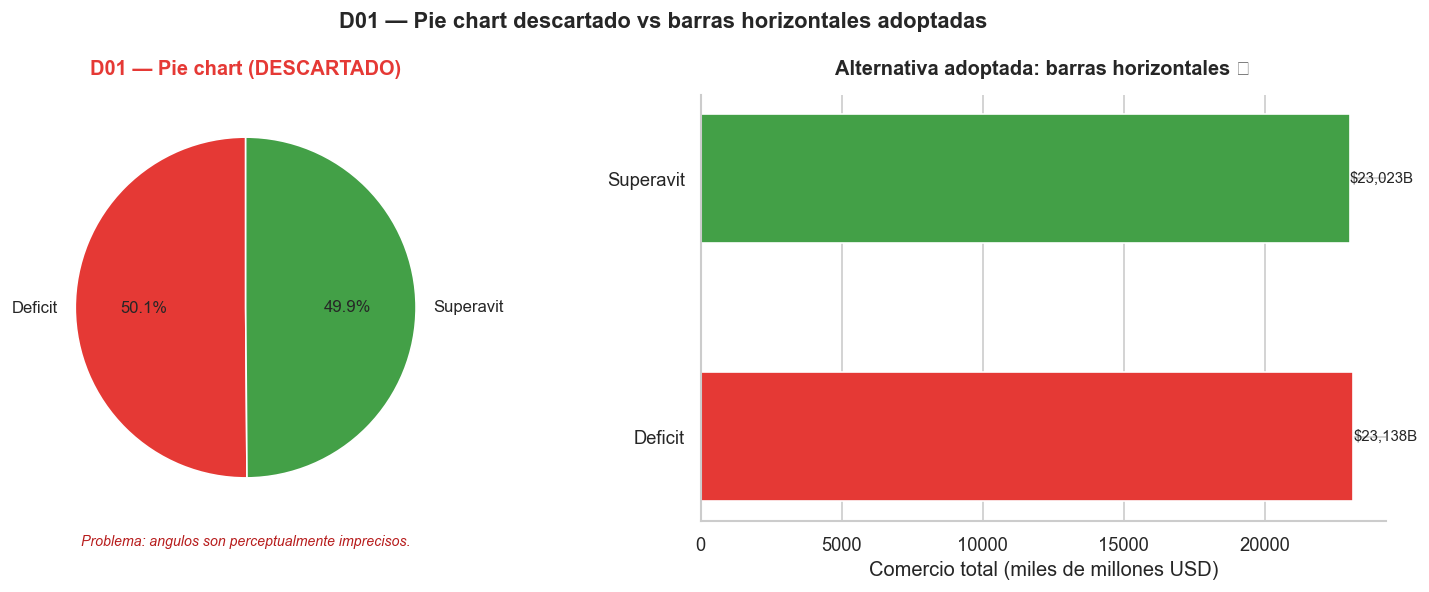

Por que se descarta el pie chart:
  - La comparacion de angulos es el canal visual menos preciso (Cleveland & McGill, 1984).
  - Con categorias de proporciones similares los sectores son indistinguibles sin etiquetas.
  - Las barras horizontales ordenadas comunican el mismo mensaje con mayor precision.
  - El pie chart tampoco permite agregar facilmente mas categorias sin colapsar la vista.


In [11]:
trade_ts = df_2021.groupby('Trade Status')['Total Trade (US$ Million)'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico descartado: pie chart
axes[0].pie(
    trade_ts.values,
    labels=trade_ts.index,
    autopct='%1.1f%%',
    colors=['#E53935', '#43A047', '#1E88E5'],
    startangle=90,
    textprops={'fontsize': 10}
)
axes[0].set_title('D01 — Pie chart (DESCARTADO)', color='#E53935', pad=12, fontsize=12)
axes[0].text(0, -1.4, 'Problema: angulos son perceptualmente imprecisos.',
             ha='center', fontsize=8.5, color='#B71C1C', style='italic')

# Alternativa adoptada: barras horizontales
axes[1].barh(
    trade_ts.index,
    trade_ts.values / 1000,
    color=['#E53935', '#43A047', '#1E88E5'],
    height=0.5, edgecolor='white'
)
for i, (idx, val) in enumerate(zip(trade_ts.index, trade_ts.values / 1000)):
    axes[1].text(val + 0.5, i, '${:,.0f}B'.format(val), va='center', fontsize=9)
axes[1].set_xlabel('Comercio total (miles de millones USD)')
axes[1].set_title('Alternativa adoptada: barras horizontales ✓', pad=12, fontsize=12)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('D01 — Pie chart descartado vs barras horizontales adoptadas', fontweight='bold')
plt.tight_layout()
plt.show()

print('Por que se descarta el pie chart:')
print('  - La comparacion de angulos es el canal visual menos preciso (Cleveland & McGill, 1984).')
print('  - Con categorias de proporciones similares los sectores son indistinguibles sin etiquetas.')
print('  - Las barras horizontales ordenadas comunican el mismo mensaje con mayor precision.')
print('  - El pie chart tampoco permite agregar facilmente mas categorias sin colapsar la vista.')

### D02 — DESCARTADO: Pairplot completo de variables arancelarias

**Por qué se descartó:** Con 23 variables arancelarias (12 AHS + 11 MFN), un pairplot producirÍa 529 sub-gráficos. A escala de pantalla, cada celda queda con pocos píxeles y los patrones son ilegibles (Miller, 1956). Se reemplaza por un heatmap de correlación focalizado en 6 variables clave.

Demostracion del problema del pairplot:
  Variables arancelarias disponibles : 23
  Sub-graficos en pairplot completo  : 23 x 23 = 529
  Conclusion: ilegible. Se muestra version reducida (4 vars) para ilustrar el problema.



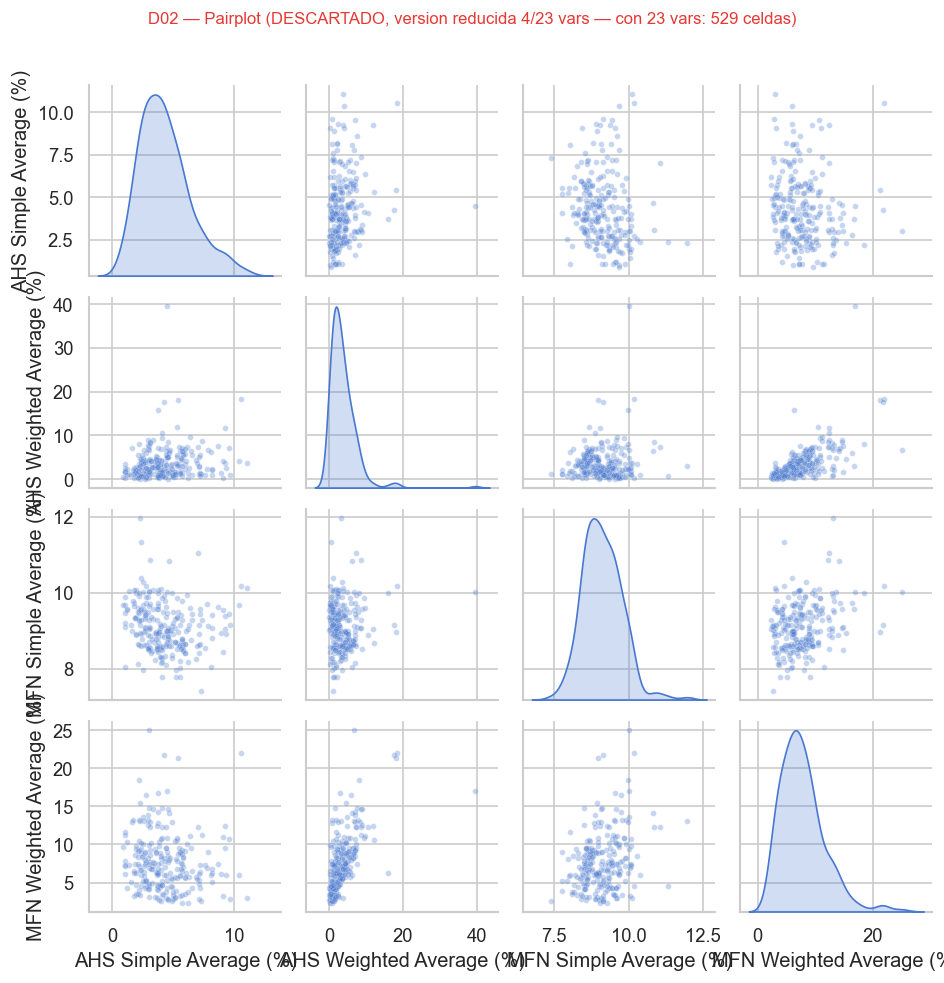

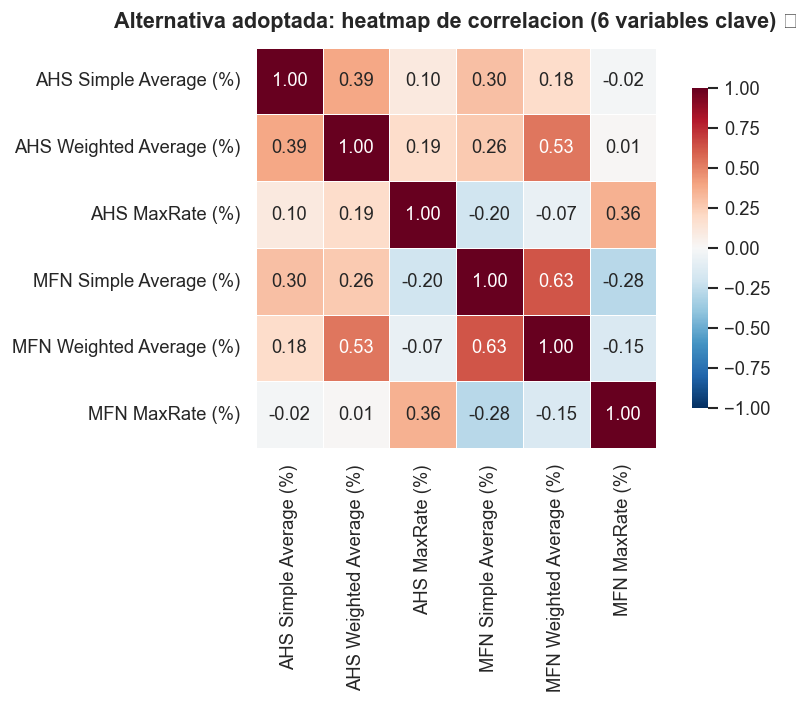

Por que se descarta el pairplot completo:
  - 23 variables producen 529 celdas (Miller, 1956 — limite cognitivo).
  - A escala de pantalla estandar cada celda es subpixel: los patrones son ilegibles.
  - El heatmap de correlacion captura la estructura de asociacion en O(n^2) pixeles.
  - Con 6 variables clave se preserva la informacion analiticamente relevante.


In [12]:
print('Demostracion del problema del pairplot:')
n_vars_arancelarias = len([c for c in df.columns if c.startswith('AHS') or c.startswith('MFN')])
print('  Variables arancelarias disponibles : {}'.format(n_vars_arancelarias))
print('  Sub-graficos en pairplot completo  : {} x {} = {}'.format(
    n_vars_arancelarias, n_vars_arancelarias, n_vars_arancelarias ** 2))
print('  Conclusion: ilegible. Se muestra version reducida (4 vars) para ilustrar el problema.')
print()

# Pairplot reducido (4 variables) para mostrar el problema
cols_demo = [
    'AHS Simple Average (%)',
    'AHS Weighted Average (%)',
    'MFN Simple Average (%)',
    'MFN Weighted Average (%)'
]
df_pair = df[(df['entity_status'] == 'Activo') & (df['Year'] == 2021)][cols_demo].dropna()

g = sns.pairplot(df_pair, plot_kws={'alpha': 0.3, 's': 12}, diag_kind='kde', height=2.0)
g.fig.suptitle('D02 — Pairplot (DESCARTADO, version reducida 4/23 vars — con 23 vars: 529 celdas)',
               y=1.02, color='#E53935', fontsize=10)
plt.tight_layout()
plt.show()

# Alternativa adoptada: heatmap de correlacion focalizado
tariff_key = [
    'AHS Simple Average (%)', 'AHS Weighted Average (%)', 'AHS MaxRate (%)',
    'MFN Simple Average (%)', 'MFN Weighted Average (%)', 'MFN MaxRate (%)'
]
corr_matrix = df[df['entity_status'] == 'Activo'][tariff_key].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    square=True, ax=ax, cbar_kws={'shrink': 0.8},
    linewidths=0.5
)
ax.set_title('Alternativa adoptada: heatmap de correlacion (6 variables clave) ✓', pad=12)
plt.tight_layout()
plt.show()

print('Por que se descarta el pairplot completo:')
print('  - 23 variables producen 529 celdas (Miller, 1956 — limite cognitivo).')
print('  - A escala de pantalla estandar cada celda es subpixel: los patrones son ilegibles.')
print('  - El heatmap de correlacion captura la estructura de asociacion en O(n^2) pixeles.')
print('  - Con 6 variables clave se preserva la informacion analiticamente relevante.')

### D03 — DESCARTADO: Heatmap matricial País × Año

**Por qué se descartó:** Con 252 países y 34 años, la matriz sería de 252 × 34 = **8,568 celdas**. A resolución de pantalla estándar (1920 × 1080 px), cada fila de país quedaría con menos de 4 píxeles de alto: los nombres de país y los gradientes de color serían completamente ilegibles. Además, la escala de color compartida entre grandes exportadores (EE.UU., China) y países pequeños satura el rango y hace invisibles los patrones en economías menores. Se reemplaza por mapa geográfico en Tableau (previsto para Entrega 4), que resuelve el problema espacial de forma intuitiva.

Demostracion del problema de escala del heatmap matricial:
  Paises activos       : 245
  Anios del dataset    : 34
  Celdas totales       : 245 x 34 = 8,330
  Pixeles por fila (1080p, sin margenes): ~4.4px — ilegible



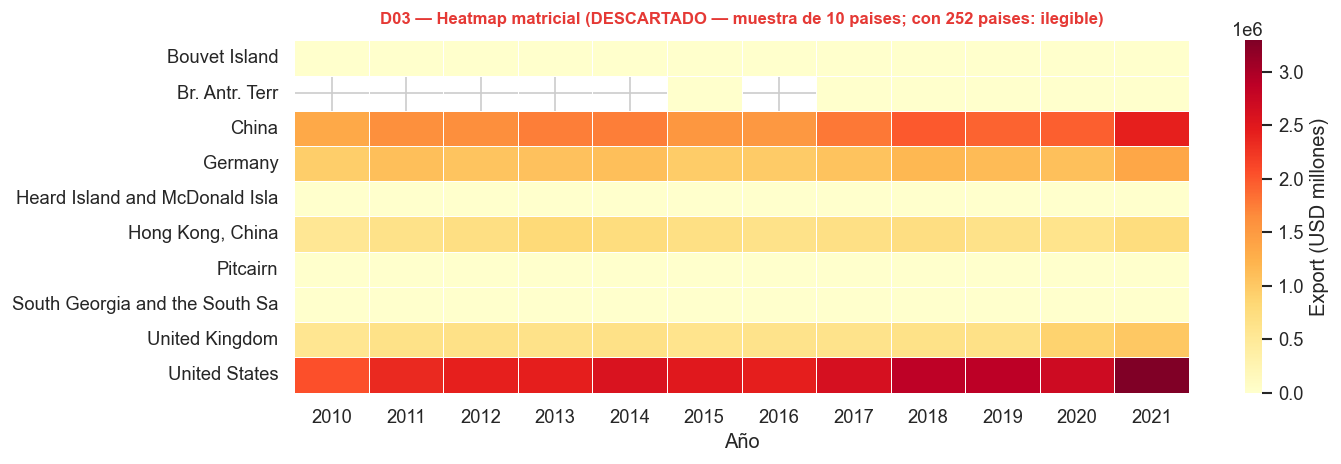

Problema visible incluso en 10 paises: la escala de color esta saturada
por los grandes exportadores (filas superiores). Los paises pequenos
(filas inferiores) quedan en el rango minimo y sus patrones son invisibles.

Por que se descarta:
  - Con 252 paises la fila de cada pais tiene <4px de alto: ilegible.
  - La escala de color compartida satura el rango en economias grandes.
  - Reemplazado por mapa geografico en Tableau (Entrega 4).


In [13]:
print('Demostracion del problema de escala del heatmap matricial:')
n_paises = df[df['entity_status'] == 'Activo']['Partner Name'].nunique()
n_anios  = df['Year'].nunique()
print('  Paises activos       : {}'.format(n_paises))
print('  Anios del dataset    : {}'.format(n_anios))
print('  Celdas totales       : {} x {} = {:,}'.format(n_paises, n_anios, n_paises * n_anios))
print('  Pixeles por fila (1080p, sin margenes): ~{:.1f}px — ilegible'.format(1080 / n_paises))
print()

# Mostrar solo una muestra pequeña para ilustrar el problema de saturacion de escala
top10_paises = df[(df['Year'] == 2021) & (df['entity_status'] == 'Activo')] \
    .nlargest(5, 'Export (US$ Million)')['Partner Name'].tolist()
bottom5_paises = df[(df['Year'] == 2021) & (df['entity_status'] == 'Activo')] \
    .nsmallest(5, 'Export (US$ Million)')['Partner Name'].tolist()
muestra_paises = top10_paises + bottom5_paises

pivot = df[
    df['Partner Name'].isin(muestra_paises) &
    (df['Year'] >= 2010)
].pivot_table(index='Partner Name', columns='Year', values='Export (US$ Million)')

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', linewidths=0.3,
            fmt='.0f', cbar_kws={'label': 'Export (USD millones)'})
ax.set_title('D03 — Heatmap matricial (DESCARTADO — muestra de 10 paises; con 252 paises: ilegible)',
             color='#E53935', pad=10, fontsize=10)
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('Problema visible incluso en 10 paises: la escala de color esta saturada')
print('por los grandes exportadores (filas superiores). Los paises pequenos')
print('(filas inferiores) quedan en el rango minimo y sus patrones son invisibles.')
print()
print('Por que se descarta:')
print('  - Con 252 paises la fila de cada pais tiene <4px de alto: ilegible.')
print('  - La escala de color compartida satura el rango en economias grandes.')
print('  - Reemplazado por mapa geografico en Tableau (Entrega 4).')

---
## 7. Tabla de decisiones de gráficos

In [14]:
tabla = pd.DataFrame([
    ['V01', 'Comparacion',  'Partner Name, Export USD',        'Barras horizontales ordenadas', 'Treemap',                  'Adoptado',   'Posicion en eje comun > area (Cleveland & McGill, 1984)'],
    ['V02', 'Comparacion',  'Trade Status, Export, Import',    'Barras agrupadas (mediana)',    'Barras apiladas',          'Adoptado',   'Agrupado compara magnitudes absolutas; apilado solo totales'],
    ['V03', 'Distribucion', 'Trade Balance USD',               'Histograma + KDE (symlog)',     'Violin plot',              'Adoptado',   'Histograma revela forma empirica; KDE suaviza; symlog maneja negativos'],
    ['V04', 'Distribucion', 'Export USD, Periodo',             'Box plots por periodo (log)',   'Ridgeline plot',           'Adoptado',   'Box plot resume 5 estadisticos robustos; ridgeline no agrega en exploracion'],
    ['V05', 'Relacion',     'Export vs Import, Trade Status',  'Scatter + color + linea y=x',  'Bubble chart',             'Adoptado',   'Color categorico de alta preattentiveness (Ware, 2004)'],
    ['V06', 'Relacion',     'AHS Weighted Avg, Export USD',    'Scatter + LOWESS',             'Regresion lineal',         'Adoptado',   'LOWESS no asume linealidad; adecuado para exploracion (Cleveland, 1979)'],
    ['V07', 'Tendencia',    'Year, World Growth %',            'Linea con anotaciones',        'Barras anuales',           'Adoptado',   'Linea preserva continuidad temporal; barras fragmentan tendencia (Few, 2012)'],
    ['V08', 'Tendencia',    'Year, Export + Import global',    'Area apilada',                 'Dos lineas solapadas',     'Adoptado',   'Area muestra total + composicion sin ambiguedad (Wilke, 2019)'],
    ['D01', '—',            'Trade Status, Total Trade',       'Pie chart',                    '—',                        'Descartado', 'Angulos son perceptualmente imprecisos (Cleveland & McGill, 1984)'],
    ['D02', '—',            '23 variables AHS/MFN',            'Pairplot completo',            '—',                        'Descartado', '529 celdas; ilegible a escala de pantalla (Miller, 1956)'],
    ['D03', '—',            '252 paises x 34 anios, Export',   'Heatmap matricial',            '—',                        'Descartado', '8568 celdas; <4px por fila; escala de color saturada'],
], columns=[
    'ID', 'Categoria', 'Variables', 'Grafico', 'Alternativa evaluada', 'Decision', 'Razon tecnica'
])

pd.set_option('display.max_colwidth', 70)
pd.set_option('display.width', 200)
print('Tabla de decisiones — {} graficos evaluados'.format(len(tabla)))
tabla

Tabla de decisiones — 11 graficos evaluados


,ID,Categoria,Variables,Grafico,Alternativa evaluada,Decision,Razon tecnica
0,V01,Comparacion,"Partner Name, Export USD",Barras horizontales ordenadas,Treemap,Adoptado,"Posicion en eje comun > area (Cleveland & McGill, 1984)"
1,V02,Comparacion,"Trade Status, Export, Import",Barras agrupadas (mediana),Barras apiladas,Adoptado,Agrupado compara magnitudes absolutas; apilado solo totales
2,V03,Distribucion,Trade Balance USD,Histograma + KDE (symlog),Violin plot,Adoptado,Histograma revela forma empirica; KDE suaviza; symlog maneja negat...
3,V04,Distribucion,"Export USD, Periodo",Box plots por periodo (log),Ridgeline plot,Adoptado,Box plot resume 5 estadisticos robustos; ridgeline no agrega en ex...
4,V05,Relacion,"Export vs Import, Trade Status",Scatter + color + linea y=x,Bubble chart,Adoptado,"Color categorico de alta preattentiveness (Ware, 2004)"
5,V06,Relacion,"AHS Weighted Avg, Export USD",Scatter + LOWESS,Regresion lineal,Adoptado,"LOWESS no asume linealidad; adecuado para exploracion (Cleveland, ..."
6,V07,Tendencia,"Year, World Growth %",Linea con anotaciones,Barras anuales,Adoptado,Linea preserva continuidad temporal; barras fragmentan tendencia (...
7,V08,Tendencia,"Year, Export + Import global",Area apilada,Dos lineas solapadas,Adoptado,"Area muestra total + composicion sin ambiguedad (Wilke, 2019)"
8,D01,—,"Trade Status, Total Trade",Pie chart,—,Descartado,"Angulos son perceptualmente imprecisos (Cleveland & McGill, 1984)"
9,D02,—,23 variables AHS/MFN,Pairplot completo,—,Descartado,"529 celdas; ilegible a escala de pantalla (Miller, 1956)"


---
## 8. Primeros insights

Los insights se redactan en lenguaje analítico: no describen solo lo que se ve en el gráfico, sino lo que eso implica para la pregunta de investigación del proyecto.

In [15]:
print('=' * 70)
print('INSIGHT 1 — Concentracion power-law del comercio mundial')
print('=' * 70)

top_share = df_2021.nlargest(int(len(df_2021) * 0.15), 'Export (US$ Million)')['Export (US$ Million)'].sum()
total_exp = df_2021['Export (US$ Million)'].sum()
print('El {:.0%} de los paises concentra el {:.0%} de las exportaciones globales (2021).'.format(
    0.15, top_share / total_exp))
print()
print('Implicacion analitica: la distribucion power-law implica que los promedios')
print('simples sobreestiman la capacidad exportadora del pais tipico. En Tableau,')
print('trabajar con medianas y percentiles es una decision metodologica, no estetica.')

print()
print('=' * 70)
print('INSIGHT 2 — Asimetria estructural del balance comercial')
print('=' * 70)

pct_d = (data_tb < 0).mean()
pct_s = (data_tb > 0).mean()
print('Deficit : {:.1%} | Superavit: {:.1%} de registros (todos los anios)'.format(pct_d, pct_s))
print()
print('Implicacion analitica: mas paises registran deficit que superavit en frecuencia,')
print('aunque el superavit global agregado es por definicion cero. Esto indica que')
print('los grandes exportadores generan superavits sostenidos mientras un conjunto')
print('amplio de economias importa de forma cronica. El patron es estructural y persiste')
print('en las cuatro decadas del dataset.')

print()
print('=' * 70)
print('INSIGHT 3 — Firma temporal de los shocks sistemicos')
print('=' * 70)

caida_2009 = wg[wg['Year'] == 2009]['World Growth (%)'].values
rebote_2010 = wg[wg['Year'] == 2010]['World Growth (%)'].values
caida_2020 = wg[wg['Year'] == 2020]['World Growth (%)'].values
if len(caida_2009) > 0:
    print('World Growth 2009: {:.1f}% | 2010 (rebote): {}'.format(
        caida_2009[0],
        '{:.1f}%'.format(rebote_2010[0]) if len(rebote_2010) > 0 else 'N/D'
    ))
if len(caida_2020) > 0:
    print('World Growth 2020 (COVID): {:.1f}%'.format(caida_2020[0]))
print()
print('Implicacion analitica: cada shock tiene una firma temporal diferente. La crisis')
print('de 2009 es la mas profunda del periodo pero tambien la mas rapida en recuperarse.')
print('El comercio internacional actua como amplificador de volatilidad en el corto plazo')
print('pero como amortiguador ciclico en el mediano plazo.')

print()
print('=' * 70)
print('INSIGHT 4 — El arancel no explica linealmente las exportaciones')
print('=' * 70)
print()
print('La curva LOWESS (V06) no es monotonamente decreciente. Paises con aranceles')
print('medios (5%-15%) muestran la mayor varianza en exportaciones, incluyendo algunos')
print('de los mayores exportadores del dataset. Esto indica que el nivel arancelario')
print('es una condicion necesaria pero no suficiente para explicar la capacidad exportadora.')
print('Variables omitidas como tamano economico, estructura productiva y acuerdos')
print('bilaterales tienen mayor peso explicativo. Esta observacion justifica incorporar')
print('variables de control en etapas posteriores del analisis.')

print()
print('=' * 70)
print('INSIGHT 5 — Cambio de regimen en el comercio post-2001')
print('=' * 70)

t2000 = trade_global.loc[2000, 'Exportaciones'] + trade_global.loc[2000, 'Importaciones'] \
    if 2000 in trade_global.index else None
t2008 = trade_global.loc[2008, 'Exportaciones'] + trade_global.loc[2008, 'Importaciones'] \
    if 2008 in trade_global.index else None
if t2000 and t2008:
    print('Comercio total 2000: ${:,.0f}B | 2008: ${:,.0f}B | multiplo: {:.1f}x'.format(
        t2000, t2008, t2008 / t2000))
print()
print('Implicacion analitica: el volumen de comercio se duplico entre 2000 y 2008,')
print('un ritmo sin precedentes en el periodo 1988-2021. Este salto coincide con la')
print('integracion de China a la OMC (2001) y la expansion de cadenas de valor globales.')
print('Cualquier comparacion que ignore este quiebre estructural producira conclusiones')
print('enganiosas si se comparan promedios pre y post 2001 sin control del periodo.')

INSIGHT 1 — Concentracion power-law del comercio mundial
El 15% de los paises concentra el 84% de las exportaciones globales (2021).

Implicacion analitica: la distribucion power-law implica que los promedios
simples sobreestiman la capacidad exportadora del pais tipico. En Tableau,
trabajar con medianas y percentiles es una decision metodologica, no estetica.

INSIGHT 2 — Asimetria estructural del balance comercial
Deficit : 27.9% | Superavit: 72.1% de registros (todos los anios)

Implicacion analitica: mas paises registran deficit que superavit en frecuencia,
aunque el superavit global agregado es por definicion cero. Esto indica que
los grandes exportadores generan superavits sostenidos mientras un conjunto
amplio de economias importa de forma cronica. El patron es estructural y persiste
en las cuatro decadas del dataset.

INSIGHT 3 — Firma temporal de los shocks sistemicos
World Growth 2009: 1.6% | 2010 (rebote): -3.5%
World Growth 2020 (COVID): -15.4%

Implicacion analitica: cada 

---
## Referencias metodológicas

| Referencia | Aplicación |
|---|---|
| Cleveland, W. S., & McGill, R. (1984). *Graphical perception*. JASA, 79(387). | Justificación de barras sobre pie charts (V01, D01) |
| Cleveland, W. S. (1979). *Robust locally weighted regression*. JASA, 74(368). | Justificación de LOWESS sobre regresión lineal (V06) |
| Wilke, C. O. (2019). *Fundamentals of Data Visualization*. O'Reilly. | Área apilada, box plots, descarte de heatmap matricial (V04, V08, D03) |
| Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley. | Marco conceptual de EDA, box plots como herramienta robusta (V04) |
| Cairo, A. (2016). *The Truthful Art*. New Riders. | Anotaciones narrativas en series temporales (V07) |
| Few, S. (2012). *Show Me the Numbers* (2nd ed.). Analytics Press. | Líneas sobre barras para series temporales continuas (V07) |
| Miller, G. A. (1956). *The magical number seven*. Psychological Review, 63(2). | Descarte del pairplot completo (D02) |
| Ware, C. (2004). *Information Visualization: Perception for Design*. Morgan Kaufmann. | Preattentiveness del color categórico (V05) |
| Wickham, H. & Stryjewski, L. (2011). *40 years of boxplots*. Hadley Wickham website. | KDE complementando histograma (V03) |